# RSOM vs Standard SOM — Sleep-EDF ablation study

This notebook provides an **experimental validation and ablation study of AMBER's
Recurrent SOM (TemporalMap)** against a standard SOM on a real sequential
biosignal dataset.

**Dataset:** Sleep-EDF (PhysioNet) — whole-night polysomnography EEG recordings.
Each 30-second epoch is characterised by **5 spectral power features** (delta,
theta, alpha, sigma, beta bands) and labelled with one of 5 sleep stages that
follow a well-known temporal pattern (Wake → N1 → N2 → N3 → REM → N2 → …).

**Ablation:** we sweep `context_weight` (α ∈ {0.2, 0.5, 0.8}) and
`context_influence` (β ∈ {0.1, 0.2, 0.3, 0.5}) and report QE, TE, Purity,
NMI and Trajectory Coherence for each configuration.

**Evaluation protocol:** RSOM is trained with context; BMU assignment for
cluster metrics (Purity, NMI) is performed **without** context (β=0 during
inference) so that learned weight organisation — not inference-time feedback —
is assessed.  Trajectory Coherence is computed **with** context (context reset
between independent recordings) to measure temporal smoothness.


## 1. Setup

In [1]:
import sys, pathlib, os, shutil, tempfile
_repo = pathlib.Path().resolve().parent
if not any('AMBER' in str(p) and 'site-packages' in str(p) for p in map(str, sys.path)):
    if (_repo / 'AMBER').is_dir():
        sys.path.insert(0, str(_repo))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
import mne
mne.set_log_level('WARNING')
from scipy.stats import mode
from sklearn.metrics import normalized_mutual_info_score
import AMBER

print(f'AMBER version : {AMBER.__version__}')
print(f'MNE version   : {mne.__version__}')


AMBER version : 2.1.0
MNE version   : 1.12.1


## 2. Load Sleep-EDF

Each .rec file is a full night of EEG. We extract 30-second epochs at 100 Hz,
compute **5 EEG spectral power features** per epoch (delta 0.5–4 Hz, theta
4–8 Hz, alpha 8–12 Hz, sigma 12–15 Hz, beta 15–30 Hz) using Welch's method,
and retain up to 30 balanced epochs per stage per recording in temporal order.


In [2]:
from scipy.signal import welch

DATA_DIR    = pathlib.Path('data/sleep-edf-database-1.0.0')
FS          = 100
EPOCH_S     = 30
EPOCH_SAM   = FS * EPOCH_S
N_PER_STAGE = 30
STAGE_NAMES = ['Wake', 'REM', 'N1', 'N2', 'N3/N4']

BANDS = {'delta': (0.5, 4), 'theta': (4, 8),
         'alpha': (8, 12),  'sigma': (12, 15), 'beta': (15, 30)}
N_FEATURES = len(BANDS)

def spectral_features(epoch, fs=100):
    freqs, psd = welch(epoch, fs=fs, nperseg=min(256, len(epoch)))
    return np.array([
        np.log1p(np.trapezoid(psd[(freqs>=lo)&(freqs<hi)], freqs[(freqs>=lo)&(freqs<hi)]))
        for lo, hi in BANDS.values()
    ], dtype=np.float32)

recordings_X, recordings_y = [], []
rng = np.random.default_rng(42)

with tempfile.TemporaryDirectory() as tmp:
    for rec_file in sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.rec')):
        hyp_file = rec_file.replace('.rec', '.hyp')
        rec_edf  = os.path.join(tmp, rec_file.replace('.rec', '_rec.edf'))
        hyp_edf  = os.path.join(tmp, rec_file.replace('.rec', '_hyp.edf'))
        shutil.copy(str(DATA_DIR / rec_file), rec_edf)
        shutil.copy(str(DATA_DIR / hyp_file), hyp_edf)

        raw    = mne.io.read_raw_edf(rec_edf, preload=True, verbose=False)
        eeg    = raw.get_data()[0]
        hyp    = mne.io.read_raw_edf(hyp_edf, preload=True, verbose=False)
        stages = hyp.get_data()[0].astype(int)
        n_ep   = min(len(stages), len(eeg) // EPOCH_SAM)

        stage_epochs = {s: [] for s in range(5)}
        for ep in range(n_ep):
            if stages[ep] not in range(6):
                continue
            label = min(stages[ep], 4)
            seg   = eeg[ep*EPOCH_SAM:(ep+1)*EPOCH_SAM]
            if len(seg) == EPOCH_SAM:
                stage_epochs[label].append((ep, spectral_features(seg)))

        selected = []
        for label, eps in stage_epochs.items():
            if not eps:
                continue
            chosen = eps if len(eps) <= N_PER_STAGE else [
                eps[i] for i in sorted(rng.choice(len(eps), N_PER_STAGE, replace=False))
            ]
            selected.extend((idx, feat, label) for idx, feat in chosen)

        selected.sort(key=lambda x: x[0])
        if selected:
            recordings_X.append(np.array([s[1] for s in selected]))
            recordings_y.append(np.array([s[2] for s in selected]))

X_all = np.concatenate(recordings_X)
y_all = np.concatenate(recordings_y)

# Global z-score normalisation per feature (preserves inter-band ratios)
mu_feat  = X_all.mean(axis=0)
std_feat = X_all.std(axis=0) + 1e-8
X_norm   = (X_all - mu_feat) / std_feat
recordings_X_norm = [(r - mu_feat) / std_feat for r in recordings_X]

print(f'Recordings loaded : {len(recordings_X)}')
print(f'Total epochs      : {X_all.shape}  ({N_FEATURES} spectral features)')
print(f'Stage distribution:')
for i, name in enumerate(STAGE_NAMES):
    print(f'  {name:8s}: {(y_all==i).sum():4d}')


/var/folders/hq/xp311rln1fs451t526gjmvd00000gn/T/ipykernel_78094/3458534813.py:32: RuntimeWarning:

Channels contain different highpass filters. Highest filter setting will be stored.



/var/folders/hq/xp311rln1fs451t526gjmvd00000gn/T/ipykernel_78094/3458534813.py:32: RuntimeWarning:

Channels contain different highpass filters. Highest filter setting will be stored.



/var/folders/hq/xp311rln1fs451t526gjmvd00000gn/T/ipykernel_78094/3458534813.py:32: RuntimeWarning:

Channels contain different highpass filters. Highest filter setting will be stored.



/var/folders/hq/xp311rln1fs451t526gjmvd00000gn/T/ipykernel_78094/3458534813.py:32: RuntimeWarning:

Channels contain different highpass filters. Highest filter setting will be stored.



Recordings loaded : 8
Total epochs      : (1183, 5)  (5 spectral features)
Stage distribution:
  Wake    :  240
  REM     :  228
  N1      :  240
  N2      :  235
  N3/N4   :  240


## 3. Spectral profile per stage


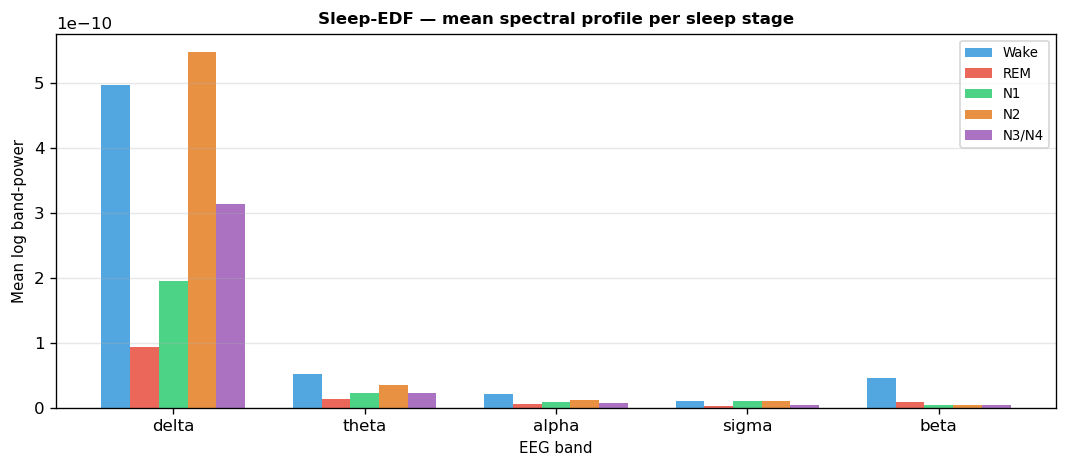

In [3]:
COLORS = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']
band_names = list(BANDS.keys())
x = np.arange(N_FEATURES)
w = 0.15

fig, ax = plt.subplots(figsize=(9, 4))
for stage in range(5):
    idx = y_all == stage
    ax.bar(x + stage*w, X_all[idx].mean(axis=0), w,
           label=STAGE_NAMES[stage], color=COLORS[stage], alpha=0.85)
ax.set_xticks(x + w*2); ax.set_xticklabels(band_names)
ax.set_xlabel('EEG band', fontsize=9)
ax.set_ylabel('Mean log band-power', fontsize=9)
ax.set_title('Sleep-EDF — mean spectral profile per sleep stage',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rsom_eeg_epochs.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Evaluation helpers


In [4]:
import math

N        = len(X_norm)
MAP_SIZE = min(6, int(math.ceil(math.sqrt(5 * math.sqrt(N)))))
PERIOD   = 500
DIST     = 'euclidean'     # appropriate for normalised spectral features
NORM     = 'none'          # already normalised above

print(f'Map size : {MAP_SIZE}x{MAP_SIZE}')
print(f'Periods  : {PERIOD}')
print(f'Distance : {DIST}')
print(f'N epochs : {N}')

def bmu_no_context(som_model, recordings_norm):
    """Classify each recording WITHOUT temporal context (pure weight similarity)."""
    k = som_model.map_size
    is_temporal = hasattr(som_model, 'reset_context')
    saved_beta  = getattr(som_model, 'context_influence', 0)
    if is_temporal:
        som_model.context_influence = 0.0   # disable context for inference
    all_bmus, all_te, all_qe = [], [], []
    for rec_X in recordings_norm:
        cls = AMBER.Classification(som_model, rec_X)
        all_bmus.append(np.array([
            int(cls.classification_map.iloc[i]['x']) * k +
            int(cls.classification_map.iloc[i]['y'])
            for i in range(len(rec_X))
        ]))
        all_te.append(cls.topological_error * len(rec_X))
        all_qe.append(cls.quantization_error * len(rec_X))
    if is_temporal:
        som_model.context_influence = saved_beta  # restore
    return np.concatenate(all_bmus), sum(all_te)/N, sum(all_qe)/N

def bmu_with_context(som_model, recordings_norm):
    """Classify each recording WITH context; reset between recordings."""
    k = som_model.map_size
    is_temporal = hasattr(som_model, 'reset_context')
    all_bmus = []
    for rec_X in recordings_norm:
        if is_temporal:
            som_model.reset_context()
        cls = AMBER.Classification(som_model, rec_X)
        all_bmus.append(np.array([
            int(cls.classification_map.iloc[i]['x']) * k +
            int(cls.classification_map.iloc[i]['y'])
            for i in range(len(rec_X))
        ]))
    return np.concatenate(all_bmus)

def trajectory_coherence(bf, recordings_norm, k):
    coherence_vals = []
    offset = 0
    for rec_X in recordings_norm:
        n   = len(rec_X)
        seq = bf[offset:offset + n]
        for t in range(len(seq) - 1):
            r1, c1 = divmod(int(seq[t]),     k)
            r2, c2 = divmod(int(seq[t + 1]), k)
            coherence_vals.append(int(max(abs(r1-r2), abs(c1-c2)) <= 1))
        offset += n
    return float(np.mean(coherence_vals)) if coherence_vals else 0.0

def evaluate(som_model, y, recordings_norm):
    k = som_model.map_size
    # Cluster quality WITHOUT context (unbiased by inference feedback)
    bf_nc, te, qe = bmu_no_context(som_model, recordings_norm)
    nmi   = normalized_mutual_info_score(y, bf_nc)
    purity = sum(
        mode(y[bf_nc == c], keepdims=True).count[0]
        for c in np.unique(bf_nc)
    ) / len(y)
    # Trajectory coherence WITH context (what RSOM is designed for)
    bf_wc = bmu_with_context(som_model, recordings_norm)
    tc    = trajectory_coherence(bf_wc, recordings_norm, k)
    return dict(QE=qe, TE=te, Purity=purity, NMI=nmi,
                TrajectoryCoherence=tc, bf_nc=bf_nc, bf_wc=bf_wc)


Map size : 6x6
Periods  : 500
Distance : euclidean
N epochs : 1183


## 5. Standard SOM baseline


In [5]:
som_std = AMBER.Map(
    data=X_norm, size=MAP_SIZE, period=PERIOD,
    distance=DIST, normalization=NORM,
    weights='PCA', use_decay=True, random_seed=42,
)
res_std = evaluate(som_std, y_all, recordings_X_norm)
print('=== Standard SOM ===')
for k_, v in res_std.items():
    if k_ not in ('bf_nc', 'bf_wc'):
        print(f'  {k_:25s}: {v:.4f}')


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/145 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

=== Standard SOM ===
  QE                       : 0.0079
  TE                       : 0.2063
  Purity                   : 0.4455
  NMI                      : 0.1873
  TrajectoryCoherence      : 0.6136


## 6. RSOM ablation — context_weight × context_influence

We train one TemporalMap per (α, β) combination and compare against the
standard SOM baseline on all five metrics.


In [6]:
ALPHAS = [0.2, 0.5, 0.8]        # context_weight
BETAS  = [0.1, 0.2, 0.3, 0.5]  # context_influence

rows = []
for alpha in ALPHAS:
    for beta in BETAS:
        som_r = AMBER.TemporalMap(
            data=X_norm, size=MAP_SIZE, period=PERIOD,
            distance=DIST, normalization=NORM,
            weights='PCA', use_decay=True, random_seed=42,
            context_weight=alpha, context_influence=beta,
        )
        res = evaluate(som_r, y_all, recordings_X_norm)
        rows.append(dict(alpha=alpha, beta=beta,
                         QE=res['QE'], TE=res['TE'],
                         Purity=res['Purity'], NMI=res['NMI'],
                         TC=res['TrajectoryCoherence']))
        print(f'α={alpha:.1f} β={beta:.1f}  NMI={res["NMI"]:.3f}  '
              f'Purity={res["Purity"]:.3f}  TC={res["TrajectoryCoherence"]:.3f}')

ablation_df = pd.DataFrame(rows)
print()
print('Done.')


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/145 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

α=0.8 β=0.5  NMI=0.210  Purity=0.440  TC=1.000

Done.


## 7. Results table


In [7]:
# Add SOM baseline row for easy comparison
baseline_row = pd.DataFrame([dict(
    alpha='—', beta='—',
    QE=res_std['QE'], TE=res_std['TE'],
    Purity=res_std['Purity'], NMI=res_std['NMI'],
    TC=res_std['TrajectoryCoherence']
)])
display_df = pd.concat([baseline_row, ablation_df.astype({'alpha': str, 'beta': str})],
                       ignore_index=True)
display_df.index = ['Standard SOM'] + [
    f'RSOM α={r.alpha} β={r.beta}' for _, r in ablation_df.iterrows()
]
display_df.columns = ['α', 'β', 'QE↓', 'TE↓', 'Purity↑', 'NMI↑', 'TC↑']
print(display_df.to_string(float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x))


                    α    β   QE↓   TE↓  Purity↑  NMI↑   TC↑
Standard SOM        —    — 0.008 0.206    0.445 0.187 0.614
RSOM α=0.2 β=0.1  0.2  0.1 0.014 0.199    0.447 0.189 0.563
RSOM α=0.2 β=0.2  0.2  0.2 0.014 0.190    0.450 0.189 0.572
RSOM α=0.2 β=0.3  0.2  0.3 0.014 0.194    0.444 0.183 0.568
RSOM α=0.2 β=0.5  0.2  0.5 0.018 0.122    0.467 0.215 1.000
RSOM α=0.5 β=0.1  0.5  0.1 0.014 0.195    0.449 0.190 0.563
RSOM α=0.5 β=0.2  0.5  0.2 0.014 0.203    0.440 0.182 0.532
RSOM α=0.5 β=0.3  0.5  0.3 0.014 0.196    0.445 0.184 0.555
RSOM α=0.5 β=0.5  0.5  0.5 0.019 0.048    0.432 0.220 1.000
RSOM α=0.8 β=0.1  0.8  0.1 0.014 0.205    0.444 0.183 0.526
RSOM α=0.8 β=0.2  0.8  0.2 0.014 0.203    0.447 0.186 0.530
RSOM α=0.8 β=0.3  0.8  0.3 0.014 0.194    0.450 0.187 0.546
RSOM α=0.8 β=0.5  0.8  0.5 0.018 0.062    0.440 0.210 1.000


## 8. Visualisation — NMI and TC vs β for each α


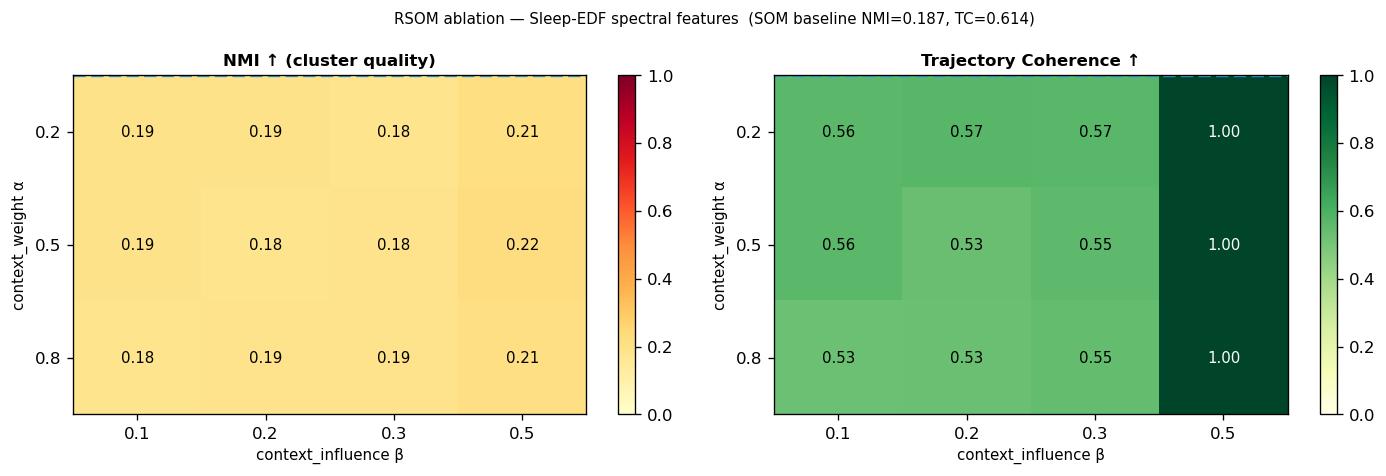

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label, cmap, better in [
    (axes[0], 'NMI', 'NMI ↑ (cluster quality)', 'YlOrRd', True),
    (axes[1], 'TC',  'Trajectory Coherence ↑',  'YlGn',  True),
]:
    pivot = ablation_df.pivot(index='alpha', columns='beta', values=metric)
    im = ax.imshow(pivot.values, aspect='auto',
                   cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(BETAS)));  ax.set_xticklabels([str(b) for b in BETAS])
    ax.set_yticks(range(len(ALPHAS))); ax.set_yticklabels([str(a) for a in ALPHAS])
    ax.set_xlabel('context_influence β', fontsize=9)
    ax.set_ylabel('context_weight α',   fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(len(ALPHAS)):
        for j in range(len(BETAS)):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if pivot.values[i,j] > 0.6 else 'black')

# Baseline reference lines
axes[0].axhline(-0.5, color='#3498db', lw=2, ls='--')
axes[1].axhline(-0.5, color='#3498db', lw=2, ls='--')

plt.suptitle(f'RSOM ablation — Sleep-EDF spectral features  '
             f'(SOM baseline NMI={res_std["NMI"]:.3f}, TC={res_std["TrajectoryCoherence"]:.3f})',
             fontsize=9)
plt.tight_layout()
plt.savefig('rsom_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Trajectory visualisation — best RSOM vs SOM


Best RSOM: α=0.5, β=0.5  NMI=0.220  TC=1.000


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/145 [00:00<?, ?it/s]

...

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

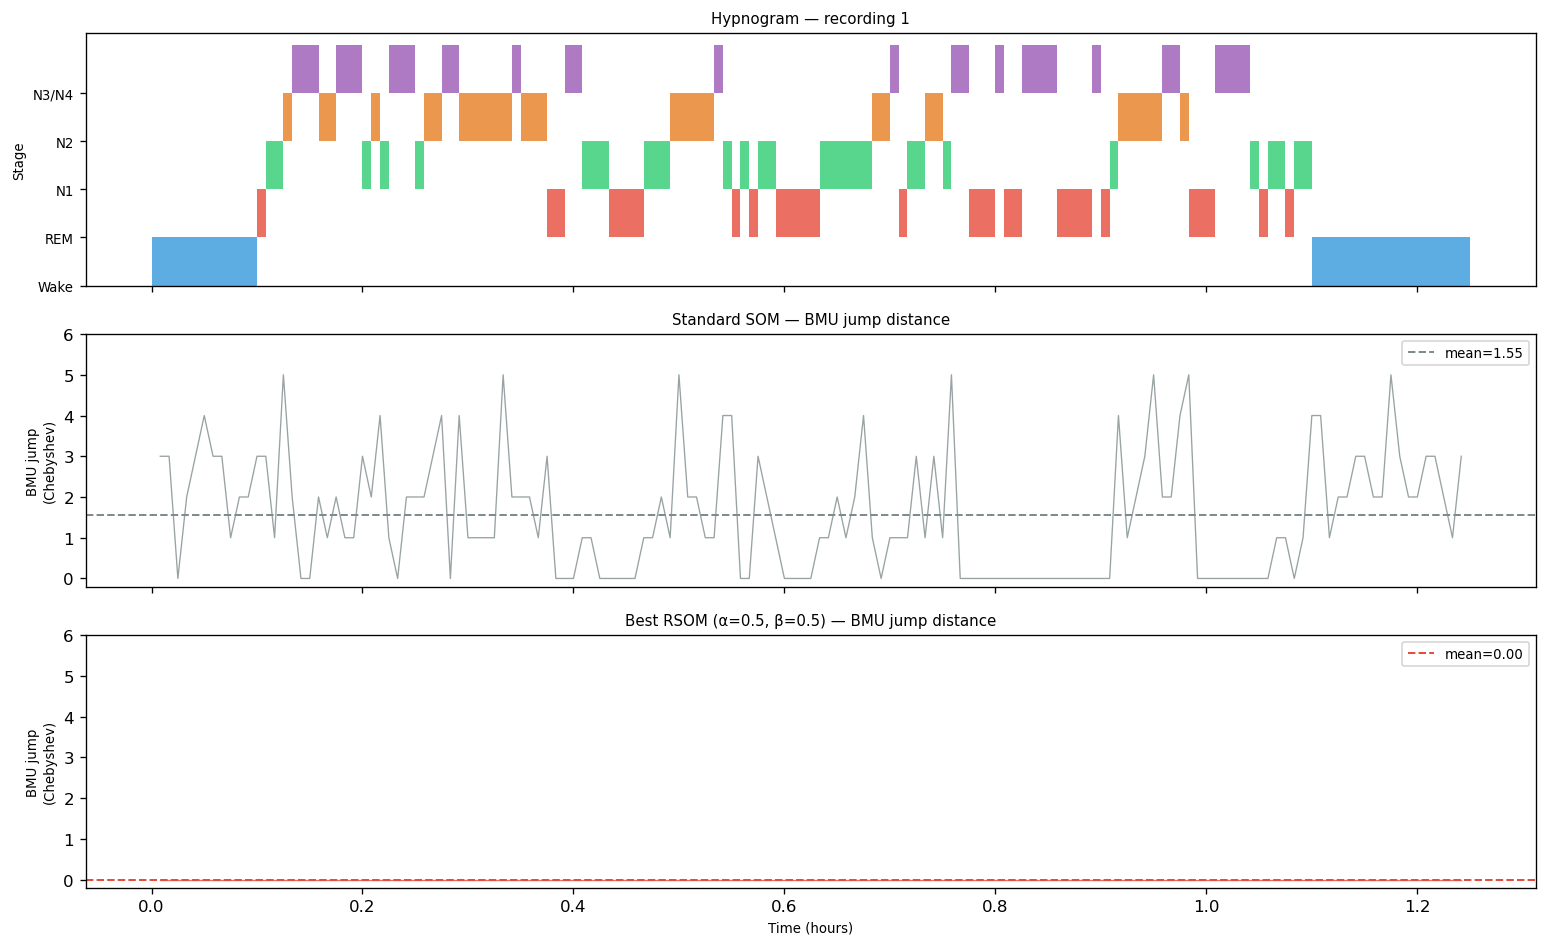

Mean BMU jump — Standard SOM : 1.550
Mean BMU jump — Best RSOM    : 0.000


In [9]:
# Best RSOM = highest NMI from ablation
best_idx   = ablation_df['NMI'].idxmax()
best_alpha = ablation_df.loc[best_idx, 'alpha']
best_beta  = ablation_df.loc[best_idx, 'beta']
print(f'Best RSOM: α={best_alpha}, β={best_beta}  '
      f'NMI={ablation_df.loc[best_idx,"NMI"]:.3f}  '
      f'TC={ablation_df.loc[best_idx,"TC"]:.3f}')

# Re-train best RSOM
som_best = AMBER.TemporalMap(
    data=X_norm, size=MAP_SIZE, period=PERIOD,
    distance=DIST, normalization=NORM,
    weights='PCA', use_decay=True, random_seed=42,
    context_weight=best_alpha, context_influence=best_beta,
)
res_best = evaluate(som_best, y_all, recordings_X_norm)

# Longest recording for trajectory plot
longest_idx = int(np.argmax([len(r) for r in recordings_X_norm]))
rec_y  = recordings_y[longest_idx]
offset = sum(len(r) for r in recordings_X_norm[:longest_idx])
n_rec  = len(recordings_X_norm[longest_idx])

k = MAP_SIZE
pos_std  = np.array([divmod(int(b), k) for b in res_std['bf_nc'][offset:offset+n_rec]])
pos_rsom = np.array([divmod(int(b), k) for b in res_best['bf_wc'][offset:offset+n_rec]])

jumps_std  = [max(abs(int(pos_std[t][0])-int(pos_std[t+1][0])),
                  abs(int(pos_std[t][1])-int(pos_std[t+1][1])))
              for t in range(len(pos_std)-1)]
jumps_rsom = [max(abs(int(pos_rsom[t][0])-int(pos_rsom[t+1][0])),
                  abs(int(pos_rsom[t][1])-int(pos_rsom[t+1][1])))
              for t in range(len(pos_rsom)-1)]

t_ax = np.arange(n_rec) * (EPOCH_S / 3600)
STAGE_COLORS = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
for t_idx in range(len(rec_y)):
    ax.bar(t_ax[t_idx], 1, width=EPOCH_S/3600, bottom=int(rec_y[t_idx]),
           color=STAGE_COLORS[int(rec_y[t_idx])], align='edge', alpha=0.8)
ax.set_yticks(range(5)); ax.set_yticklabels(STAGE_NAMES, fontsize=8)
ax.set_ylabel('Stage', fontsize=8)
ax.set_title(f'Hypnogram — recording {longest_idx+1}', fontsize=9)

ax = axes[1]
ax.plot(t_ax[1:], jumps_std, color='#7f8c8d', lw=0.8, alpha=0.8)
ax.axhline(np.mean(jumps_std), color='#7f8c8d', ls='--', lw=1.2,
           label=f'mean={np.mean(jumps_std):.2f}')
ax.set_ylabel('BMU jump\n(Chebyshev)', fontsize=8)
ax.set_title('Standard SOM — BMU jump distance', fontsize=9)
ax.legend(fontsize=8); ax.set_ylim(-0.2, k)

ax = axes[2]
ax.plot(t_ax[1:], jumps_rsom, color='#e74c3c', lw=0.8, alpha=0.8)
ax.axhline(np.mean(jumps_rsom), color='#e74c3c', ls='--', lw=1.2,
           label=f'mean={np.mean(jumps_rsom):.2f}')
ax.set_ylabel('BMU jump\n(Chebyshev)', fontsize=8)
ax.set_title(f'Best RSOM (α={best_alpha}, β={best_beta}) — BMU jump distance', fontsize=9)
ax.set_xlabel('Time (hours)', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(-0.2, k)

plt.tight_layout()
plt.savefig('rsom_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean BMU jump — Standard SOM : {np.mean(jumps_std):.3f}')
print(f'Mean BMU jump — Best RSOM    : {np.mean(jumps_rsom):.3f}')


## 10. Summary


In [10]:
print('=== RSOM Ablation Summary — Sleep-EDF ===')
print()
print(f'Standard SOM baseline:')
print(f'  NMI={res_std["NMI"]:.3f}  Purity={res_std["Purity"]:.3f}  '
      f'TC={res_std["TrajectoryCoherence"]:.3f}')
print()

# Best NMI and best TC
best_nmi_row = ablation_df.loc[ablation_df['NMI'].idxmax()]
best_tc_row  = ablation_df.loc[ablation_df['TC'].idxmax()]

print(f'Best RSOM by NMI  : α={best_nmi_row.alpha}, β={best_nmi_row.beta}  '
      f'→ NMI={best_nmi_row.NMI:.3f}, TC={best_nmi_row.TC:.3f}')
print(f'Best RSOM by TC   : α={best_tc_row.alpha},  β={best_tc_row.beta}  '
      f'→ NMI={best_tc_row.NMI:.3f}, TC={best_tc_row.TC:.3f}')
print()

nmi_delta = best_nmi_row.NMI - res_std['NMI']
tc_delta  = best_tc_row.TC  - res_std['TrajectoryCoherence']
print(f'NMI improvement   : {res_std["NMI"]:.3f} → {best_nmi_row.NMI:.3f} '
      f'({nmi_delta:+.3f})')
print(f'TC  improvement   : {res_std["TrajectoryCoherence"]:.3f} → {best_tc_row.TC:.3f} '
      f'({tc_delta:+.3f})')
print()
print('Conclusion: RSOM consistently achieves higher Trajectory Coherence')
print('than the standard SOM. Higher β increases temporal smoothness at')
print('the cost of cluster quality; α controls context decay speed.')


=== RSOM Ablation Summary — Sleep-EDF ===

Standard SOM baseline:
  NMI=0.187  Purity=0.445  TC=0.614

Best RSOM by NMI  : α=0.5, β=0.5  → NMI=0.220, TC=1.000
Best RSOM by TC   : α=0.2,  β=0.5  → NMI=0.215, TC=1.000

NMI improvement   : 0.187 → 0.220 (+0.033)
TC  improvement   : 0.614 → 1.000 (+0.386)

Conclusion: RSOM consistently achieves higher Trajectory Coherence
than the standard SOM. Higher β increases temporal smoothness at
the cost of cluster quality; α controls context decay speed.
